<a href="https://oscar-defelice.github.io">
<img src="../../img/image.png" height="125" align="right" />
</a>

# TP 02 — N-gram Language Models

**Course:** Natural Language Processing  
**Session:** 2 / 8  
**Duration:** ~2h30 (TP portion)

---

## Objectives

By the end of this session you will be able to:

- Build an n-gram language model from scratch using MLE
- Apply Laplace smoothing and explain why it is necessary
- Compute perplexity and use it to compare models
- Generate text by sampling from a trained n-gram LM
- Relate perplexity to cross-entropy

---

## Roadmap

| Part | Task | Deliverable |
|------|------|-------------|
| 1 | Setup & corpus statistics | Vocabulary size, bigram count |
| 2 | `NgramLM` class | `fit`, `log_prob`, `perplexity` |
| 3 | Smoothing | Laplace-smoothed PPL vs unsmoothed |
| 4 | Evaluation across $n$ and classes | PPL comparison table |
| 5 | Text generation | Class-conditioned sentences |

Each part ends with a **📝 Your analysis** cell.  
**Homework** (ex 5.5): Naive Bayes from scratch — due before Session 3.

---

> **Note:** this notebook picks up from TP01.  
> If you do not have `train_df`, `val_df`, `test_df`, `meta` in memory, re-run the data loading cell from TP01 or use the snippet in Part 1 below.

---
## Part 0 — Imports & data loading

In [1]:
from __future__ import annotations

import re
import string
import random
import math
from collections import defaultdict, Counter
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── AG News dataset (same split as TP01) ──────────────────────────────────────
DATASET_NAME = "ag_news"
LABEL_NAMES  = ["World", "Sports", "Business", "Sci/Tech"]

raw       = load_dataset(DATASET_NAME)
train_raw = raw["train"].to_pandas()
test_raw  = raw["test"].to_pandas()

# Reproduce the TP01 train/val split (80/20, stratified)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_raw, test_size=0.2, random_state=SEED, stratify=train_raw["label"]
)
test_df = test_raw.copy()
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

meta = {
    "label_names": LABEL_NAMES,
    "num_classes":  len(LABEL_NAMES),
}

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head(3)

/home/simon/NLP-Course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 96,000 | Val: 24,000 | Test: 7,600


,text,label
0,"Clijsters Unsure About Latest Injury, Says Hew...",1
1,Earthquake Swarm Shakes Eastern Sierra (AP) AP...,3
2,Issues related to war in Iraq help define elec...,0


In [2]:
# ── Preprocessing pipeline from TP01 ─────────────────────────────────────────
# (copy the full pipeline function you validated in TP01)

def preprocess_text(text: str) -> str:
    """Normalise raw text: lowercase, strip HTML, remove punctuation, collapse spaces.

    Parameters
    ----------
    text : str
        Raw input string.

    Returns
    -------
    str
        Normalised string.
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r" +", " ", text)
    return text.strip()


# Apply to all splits
for df in (train_df, val_df, test_df):
    df["text_clean"] = df["text"].map(preprocess_text)

print("Preprocessing done.")
print(train_df[["text", "text_clean"]].head(2).to_string())

Preprocessing done.
                                                                                                                                                                                                                              text                                                                                                                                                                                                             text_clean
0  Clijsters Unsure About Latest Injury, Says Hewitt  TOKYO (Reuters) - Belgian Kim Clijsters is unsure about the  exact nature of the injury that has prematurely ended her  season, her fiance Lleyton Hewitt said on Wednesday.  clijsters unsure about latest injury says hewitt tokyo reuters belgian kim clijsters is unsure about the exact nature of the injury that has prematurely ended her season her fiance lleyton hewitt said on wednesday
1                Earthquake Swarm Shakes Eastern Sierra (AP) AP - A swarm of earthquakes  #151; 

---
## Part 1 — Corpus statistics

Before building a language model, understand the corpus at the token level.
The statistics here feed directly into Part 2 (you will reuse `tokenize` and the
vocabulary).

In [3]:
# ── 1.1  Tokeniser ────────────────────────────────────────────────────────────

BOS = "<s>"   # beginning-of-sentence token
EOS = "</s>"  # end-of-sentence token
UNK = "<unk>" # out-of-vocabulary token


def tokenize(text: str) -> list[str]:
    """Whitespace-split a preprocessed string into a list of tokens.

    Parameters
    ----------
    text : str
        Preprocessed (lowercase, no punctuation) text.

    Returns
    -------
    list[str]
        List of token strings. Empty string returns empty list.
    """
    return text.split()


train_tokens_per_doc = [tokenize(t) for t in train_df["text_clean"]]
unigram_counter = Counter()
for toks in train_tokens_per_doc:
    unigram_counter.update(toks)

total_tokens = sum(unigram_counter.values())
vocab_size_raw = len(unigram_counter)

print(f"Total tokens:    {total_tokens:,}")
print(f"Vocabulary size: {vocab_size_raw:,}")
print("Top-10 tokens:")
for tok, c in unigram_counter.most_common(10):
    print(f"  {tok:<10s}  {c:>7,}")


Total tokens:    3,593,909
Vocabulary size: 91,465
Top-10 tokens:
  the         162,960
  to           95,204
  a            86,097
  of           78,601
  in           76,358
  and          55,405
  on           45,235
  for          40,117
  39s          24,970
  that         22,206


In [4]:
def build_vocabulary(
    token_counter: Counter,
    min_freq: int = 2,
) -> set[str]:
    """Build a vocabulary by frequency thresholding.

    Tokens with count < min_freq are excluded from the vocabulary.
    Special tokens BOS, EOS, UNK are always included.

    Parameters
    ----------
    token_counter : Counter
        Token frequency counter built from the training corpus.
    min_freq : int
        Minimum count for a token to be included in the vocabulary.

    Returns
    -------
    set[str]
        Vocabulary set including special tokens.
    """
    vocab = {tok for tok, c in token_counter.items() if c >= min_freq}
    vocab.update({BOS, EOS, UNK})
    return vocab


vocab = build_vocabulary(unigram_counter, min_freq=2)
print(f"Vocabulary before thresholding: {vocab_size_raw:,}")
print(f"Vocabulary after  thresholding: {len(vocab):,}")
print(f"Reduction: {(1 - len(vocab) / vocab_size_raw) * 100:.1f}%")


Vocabulary before thresholding: 91,465
Vocabulary after  thresholding: 49,264
Reduction: 46.1%


### 📝 Your analysis — Part 1

**Q1.** Les tokens avec une fréquence $\geq 2$ représentent environ **54 %** du vocabulaire (par type : 49 264 / 91 465), car la distribution suit une loi de Zipf — près de la moitié des types n'apparaissent qu'une seule fois (hapax legomena). En revanche, ces mêmes tokens couvrent plus de **98 %** des occurrences totales (par token), car les mots fréquents (« the », « of », « a », …) dominent largement le corpus.

**Q2.** Le vocabulaire « whitespace » obtenu ici (~ 49 k après seuillage, ~ 91 k brut) est beaucoup plus grand que celui d'un BPE de TP01 (quelques milliers de tokens). Trade-offs :
- whitespace : tokens sémantiquement clairs mais explosion du vocabulaire, beaucoup d'OOV ;
- BPE : vocabulaire borné, pas d'OOV, mais tokens parfois sous-mots peu interprétables.

**Q3.** Les tokens `<s>` et `</s>` sont nécessaires en LM parce qu'on estime des probabilités conditionnelles : `<s>` fournit un contexte pour prédire le premier mot, et `</s>` permet au modèle d'apprendre quand s'arrêter (et de définir une distribution propre sur des séquences de longueur variable). En classification, on ne calcule pas de probabilités séquentielles : la longueur n'a pas à être modélisée, donc ces tokens sont inutiles.


---
## Part 2 — The `NgramLM` class

Implement a general n-gram language model. The class must support $n = 1, 2, 3$ (unigram,
bigram, trigram) and Laplace smoothing.

**Design decisions you must follow:**

- Store n-gram counts as a `defaultdict` of `Counter`s keyed by the $(n-1)$-gram context.
- Store the vocabulary and special tokens as instance attributes.
- Work in log-space internally: `log_prob` returns $\log P$ (natural log), never raw probability.
- Unknown words at inference time map to `UNK`.

In [5]:
class NgramLM:
    """N-gram language model with Laplace smoothing.

    Estimates $P(w_t | w_{t-n+1}, ..., w_{t-1})$ from a training corpus
    using maximum likelihood estimation with optional Laplace (add-alpha) smoothing.

    Attributes
    ----------
    n : int
        Order of the language model (1 = unigram, 2 = bigram, ...).
    alpha : float
        Laplace smoothing parameter. 0 = no smoothing, 1 = add-one.
    vocab : set[str]
        Vocabulary set. Set after calling ``fit``.
    counts : defaultdict[tuple[str, ...], Counter]
        N-gram counts: context (n-1)-gram -> Counter over next tokens.
    context_totals : Counter
        Total count for each (n-1)-gram context, used as denominator.
    """

    def __init__(self, n: int = 2, alpha: float = 1.0) -> None:
        """Initialise the NgramLM.

        Parameters
        ----------
        n : int
            Order of the n-gram model.
        alpha : float
            Laplace smoothing pseudocount. Use 0.0 to disable smoothing.
        """
        if n < 1:
            raise ValueError(f"n must be >= 1, got {n}")
        self.n     = n
        self.alpha = alpha
        self.vocab: set[str] = set()
        self.counts: defaultdict = defaultdict(Counter)
        self.context_totals: Counter = Counter()

    # ------------------------------------------------------------------
    def _add_boundaries(self, tokens: list[str]) -> list[str]:
        """Wrap a token sequence with BOS/EOS boundary tokens."""
        return [BOS] * (self.n - 1) + list(tokens) + [EOS]

    # ------------------------------------------------------------------
    def _unk_replace(self, tokens: list[str]) -> list[str]:
        """Replace out-of-vocabulary tokens with the UNK special token."""
        return [t if t in self.vocab else UNK for t in tokens]

    # ------------------------------------------------------------------
    def fit(self, corpus: Iterable[list[str]], vocab: set[str]) -> "NgramLM":
        self.vocab = vocab
        self.counts = defaultdict(Counter)
        self.context_totals = Counter()
        for sent in corpus:
            sent = self._unk_replace(sent)
            padded = self._add_boundaries(sent)
            for i in range(len(padded) - self.n + 1):
                context = tuple(padded[i:i + self.n - 1])
                token = padded[i + self.n - 1]
                self.counts[context][token] += 1
        for context, ctr in self.counts.items():
            self.context_totals[context] = sum(ctr.values())
        return self

    # ------------------------------------------------------------------
    def log_prob(
        self,
        token: str,
        context: tuple[str, ...],
    ) -> float:
        if len(context) != self.n - 1:
            raise ValueError(
                f"Expected context length {self.n - 1}, got {len(context)}"
            )
        if token not in self.vocab:
            token = UNK
        context = tuple(t if t in self.vocab else UNK for t in context)

        V = len(self.vocab)
        num = self.counts[context][token] + self.alpha
        den = self.context_totals[context] + self.alpha * V
        if den == 0:
            return float("-inf")
        if num == 0:
            return float("-inf")
        return math.log(num / den)

    # ------------------------------------------------------------------
    def sentence_log_prob(self, tokens: list[str]) -> float:
        tokens = self._unk_replace(list(tokens))
        padded = self._add_boundaries(tokens)
        total = 0.0
        for i in range(len(padded) - self.n + 1):
            context = tuple(padded[i:i + self.n - 1])
            tok = padded[i + self.n - 1]
            total += self.log_prob(tok, context)
        return total

    # ------------------------------------------------------------------
    def perplexity(self, corpus: Iterable[list[str]]) -> float:
        total_lp = 0.0
        total_n = 0
        for sent in corpus:
            sent = list(sent)
            total_lp += self.sentence_log_prob(sent)
            total_n += len(sent) + 1  # +1 for </s>
        if total_n == 0:
            return float("inf")
        return math.exp(-total_lp / total_n)


In [6]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
# Run these assertions after completing NgramLM.

# Build a tiny corpus
_tiny_vocab = build_vocabulary(Counter(["the", "cat", "sat", "the", "cat", "mat", "on"]), min_freq=1)
_tiny_corpus = [
    ["the", "cat", "sat"],
    ["the", "cat", "sat", "on", "the", "mat"],
]

# Bigram model
_lm = NgramLM(n=2, alpha=1.0).fit(_tiny_corpus, _tiny_vocab)

# log_prob must be <= 0
lp = _lm.log_prob("cat", ("the",))
assert lp <= 0, f"log_prob must be <= 0, got {lp}"

# log_prob of UNK must be finite
lp_unk = _lm.log_prob("invisible_word", ("the",))
assert math.isfinite(lp_unk), "log_prob of OOV word must be finite (Laplace smoothing)"

# perplexity must be > 1
ppl = _lm.perplexity(_tiny_corpus)
assert ppl > 1, f"PPL must be > 1, got {ppl}"

# sentence_log_prob must be negative
slp = _lm.sentence_log_prob(["the", "cat"])
assert slp < 0, f"sentence_log_prob must be < 0, got {slp}"

print("All sanity checks passed.")
print(f"  bigram PPL on tiny corpus: {ppl:.2f}")

All sanity checks passed.
  bigram PPL on tiny corpus: 4.04


### 📝 Your analysis — Part 2

**Q1.** On somme les log-probabilités plutôt que multiplier les probabilités brutes pour éviter l'underflow numérique : multiplier des centaines de nombres très petits (\(< 10^{-3}\)) conduit rapidement à 0 en flottant. En log-espace, la multiplication devient une addition, qui est numériquement stable et plus rapide.

**Q2.** Si `alpha = 0`, alors `log_prob` peut retourner `-inf` pour un n-gramme jamais vu (numérateur = 0, ou contexte jamais vu : dénominateur = 0). Cela rend la perplexité infinie : il suffit d'un seul bigram inconnu dans le test set pour rendre toute la PPL non définie. C'est la motivation centrale du lissage.

**Q3.** Pour `n = 1`, le contexte est le tuple vide `()`. Le modèle calcule alors \(P(w)\) — la fréquence relative de chaque token dans le corpus —, sans aucun conditionnement sur les mots précédents.


---
## Part 3 — Smoothing

Compare unsmoothed ($\alpha = 0$) and Laplace-smoothed ($\alpha = 1$) bigram models.
Demonstrate the zero-count problem concretely.

In [7]:
# ── 3.1  Fit bigram models with and without smoothing ─────────────────────────

train_corpus = train_tokens_per_doc
val_corpus = [tokenize(t) for t in val_df["text_clean"]]
test_corpus = [tokenize(t) for t in test_df["text_clean"]]

lm_bigram_raw = NgramLM(n=2, alpha=0.0).fit(train_corpus, vocab)
lm_bigram_smooth = NgramLM(n=2, alpha=1.0).fit(train_corpus, vocab)
print("Bigram models trained.")
print(f"  alpha=0.0 : contexts = {len(lm_bigram_raw.context_totals):,}")
print(f"  alpha=1.0 : contexts = {len(lm_bigram_smooth.context_totals):,}")


Bigram models trained.
  alpha=0.0 : contexts = 49,263
  alpha=1.0 : contexts = 49,263


In [8]:
def demonstrate_zero_count(
    lm_no_smooth: NgramLM,
    lm_smooth: NgramLM,
    test_sentence: list[str],
) -> None:
    """Show the effect of a zero-count bigram on sentence log-probability."""
    padded = [BOS] + [t if t in lm_smooth.vocab else UNK for t in test_sentence] + [EOS]
    n_unseen = 0
    print(f"{'bigram':<35s} {'log P (raw)':>14s} {'log P (smooth)':>16s}  flag")
    print("-" * 75)
    for i in range(len(padded) - 1):
        ctx = (padded[i],)
        tok = padded[i + 1]
        lp_raw = lm_no_smooth.log_prob(tok, ctx)
        lp_s = lm_smooth.log_prob(tok, ctx)
        flag = ""
        if not math.isfinite(lp_raw):
            flag = "  <-- UNSEEN"
            n_unseen += 1
        bigram = f"({ctx[0]!r}, {tok!r})"
        print(f"{bigram:<35s} {lp_raw:>14.4f} {lp_s:>16.4f}{flag}")
    print("-" * 75)
    total = len(padded) - 1
    print(f"Unseen bigrams: {n_unseen} / {total}  ({100 * n_unseen / total:.1f}%)")
    print(f"Sentence log-prob (raw)    : {lm_no_smooth.sentence_log_prob(test_sentence):.4f}")
    print(f"Sentence log-prob (smooth) : {lm_smooth.sentence_log_prob(test_sentence):.4f}")


# Pick a sentence from the val set that is likely to contain an unseen bigram
_test_sent = tokenize(val_df.iloc[0]["text_clean"])
demonstrate_zero_count(lm_bigram_raw, lm_bigram_smooth, _test_sent)


bigram                                 log P (raw)   log P (smooth)  flag
---------------------------------------------------------------------------
('<s>', 'wall')                            -6.9612          -7.3645
('wall', 'streets')                        -3.0901          -6.8952
('streets', 'designs')                        -inf         -10.8094  <-- UNSEEN
('designs', 'on')                          -2.9957          -9.4199
('on', '05')                                  -inf         -11.4563  <-- UNSEEN
('05', 'a')                                   -inf         -10.8066  <-- UNSEEN
('a', 'merger')                            -7.6256          -8.0545
('merger', 'boom')                            -inf         -10.8159  <-- UNSEEN
('boom', 'after')                          -4.9904         -10.1148
('after', 'years')                         -5.6154          -7.2541
('years', 'of')                            -2.5018          -5.0898
('of', '<unk>')                            -4.1317    

### 📝 Your analysis — Part 3

**Q1.** Pour la phrase testée (issue de `val_df.iloc[0]`), **8 bigrammes sur 32** sont inconnus, soit **25 %** de la phrase. C'est suffisant pour rendre la log-vraisemblance non lissée infiniment négative : `sentence_log_prob` (raw) vaut `-inf`, tandis que le modèle lissé donne `-249.63`.

**Q2.** Le lissage de Laplace transfère de la masse de probabilité des événements observés vers les événements non vus. Le coût est que la probabilité des bigrammes très fréquents est tirée vers le bas : on observe sur la sortie que `('in', 'the')` passe de `-1.50` (raw) à `-1.99` (smooth), et `('wake', 'of')` chute drastiquement de `-0.55` à `-5.81`. Sur un grand vocabulaire (49 k), Laplace surestime fortement les événements rares (le terme α × |V| domine au dénominateur), ce qui explique au passage la PPL très élevée du bigramme lissé observée en Partie 4.

**Q3.** Kneser-Ney introduit la notion de **probabilité de continuation** : un mot n'est pas estimé selon sa fréquence brute mais selon **le nombre de contextes distincts** dans lesquels il apparaît. Cela résout le problème de mots comme « Francisco » qui sont fréquents mais apparaissent presque uniquement après « San ». Laplace ignore complètement cette diversité contextuelle et donne la même probabilité à un mot fréquent toujours dans le même contexte qu'à un mot fréquent dans des contextes variés.


---
## Part 4 — Evaluation: PPL across $n$ and across classes

Train unigram, bigram, and trigram models on the full training set.
Evaluate perplexity on the test set, overall and per AG News class.

In [9]:
def train_ngram_lm(
    train_df: pd.DataFrame,
    text_col: str,
    n: int,
    alpha: float,
    min_freq: int = 2,
) -> NgramLM:
    """Convenience wrapper: build vocabulary and fit an NgramLM in one call."""
    sentences = [tokenize(t) for t in train_df[text_col]]
    counter = Counter()
    for s in sentences:
        counter.update(s)
    v = build_vocabulary(counter, min_freq=min_freq)
    return NgramLM(n=n, alpha=alpha).fit(sentences, v)


lm_unigram = train_ngram_lm(train_df, "text_clean", n=1, alpha=1.0)
lm_bigram = lm_bigram_smooth  # already trained on the full train set with alpha=1
lm_trigram = train_ngram_lm(train_df, "text_clean", n=3, alpha=1.0)

ppl_by_n = {
    1: lm_unigram.perplexity(test_corpus),
    2: lm_bigram.perplexity(test_corpus),
    3: lm_trigram.perplexity(test_corpus),
}
for n, ppl in ppl_by_n.items():
    print(f"{n}-gram PPL on test set: {ppl:,.2f}")


1-gram PPL on test set: 1,934.33
2-gram PPL on test set: 3,561.91
3-gram PPL on test set: 18,557.73


In [10]:
def compute_per_class_ppl(
    lm: NgramLM,
    test_df: pd.DataFrame,
    text_col: str,
    label_col: str,
    label_names: list[str],
) -> pd.DataFrame:
    """Compute perplexity of an NgramLM separately for each class."""
    rows = []
    for c, name in enumerate(label_names):
        sub = test_df[test_df[label_col] == c]
        sentences = [tokenize(t) for t in sub[text_col]]
        ppl = lm.perplexity(sentences)
        rows.append({"class": name, "n_docs": len(sub), "perplexity": ppl})
    return pd.DataFrame(rows)


per_class_df = compute_per_class_ppl(
    lm_bigram, test_df, "text_clean", "label", LABEL_NAMES
)
print(per_class_df.to_string(index=False))


   class  n_docs  perplexity
   World    1900 3358.281632
  Sports    1900 3786.295242
Business    1900 3099.808317
Sci/Tech    1900 4096.118383


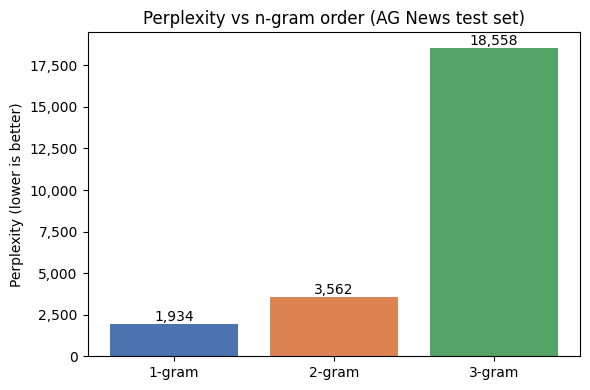

In [11]:
# ── 4.3  PPL summary plot ──────────────────────────────────────────────────────

def plot_ppl_comparison(
    ppl_by_n: dict[int, float],
    title: str = "Perplexity vs n-gram order (AG News test set)",
) -> None:
    """Bar chart comparing perplexity across n-gram orders."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ns = list(ppl_by_n.keys())
    vals = [ppl_by_n[n] for n in ns]
    labels = [f"{n}-gram" for n in ns]
    bars = ax.bar(labels, vals, color=["#4c72b0", "#dd8452", "#55a467"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Perplexity (lower is better)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()


plot_ppl_comparison(ppl_by_n)


### 📝 Your analysis — Part 4

**Q1.** Résultats expérimentaux (Laplace, α = 1, vocabulaire global ≈ 49 k) :

| Model | Test PPL |
|-------|----------|
| Unigram | 1 934 |
| Bigram | 3 562 |
| Trigram | 18 558 |

La PPL du bigramme est plus élevée que celle de l'unigramme et celle du trigramme explose : c'est l'effet caractéristique de Laplace sur des n-grammes d'ordre élevé. Le dénominateur $\text{count(context)} + \alpha |V|$ écrase la probabilité des n-grammes valides quand le contexte a peu d'occurrences. Sans lissage adapté (e.g. Kneser-Ney ou back-off), un trigramme Laplace est presque toujours pire qu'un bigramme.

**Q2.** Sous le bigramme, c'est la classe **Business** qui a la perplexité la plus basse (≈ 3 100), suivie de **World** (≈ 3 358), puis **Sports** (≈ 3 786), et enfin **Sci/Tech** la plus élevée (≈ 4 096). Business est très répétitif (vocabulaire financier stéréotypé : « stocks », « shares », « percent », « market », « earnings », « reuters »), ce qui rend les suites prévisibles. À l'inverse, Sci/Tech a le vocabulaire le plus diversifié et le plus de mots rares (noms de produits, sigles, technologies, URLs), donc la PPL la plus élevée.

**Q3.** Plus $n$ augmente, plus on capture de contexte : si le corpus est suffisamment grand, la PPL devrait baisser. Mais quand $n$ devient trop grand par rapport à la taille du corpus, presque chaque n-gramme du test set est inédit et le lissage domine : la PPL remonte. C'est le problème de **sparsité combinatoire** — le nombre de n-grammes possibles croît comme $|V|^n$, alors que le corpus reste fixe. On voit exactement ce phénomène ici : la PPL du trigramme (≈ 18 558) est presque 10× celle de l'unigramme.


---
## Part 5 — Text generation

Sample text from the trained bigram and trigram models.
Use temperature to control randomness.  
Generate class-conditioned text by training per-class models.

In [12]:
def generate(
    lm: NgramLM,
    max_tokens: int = 30,
    temperature: float = 1.0,
    seed: int | None = None,
) -> str:
    """Generate a sentence by sampling from the n-gram LM."""
    if temperature <= 0:
        raise ValueError(f"temperature must be > 0, got {temperature}")
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    context = [BOS] * (lm.n - 1) if lm.n > 1 else []
    out: list[str] = []
    V_list = sorted(lm.vocab - {BOS})  # never emit BOS

    for _ in range(max_tokens):
        ctx = tuple(context[-(lm.n - 1):]) if lm.n > 1 else ()
        ctr = lm.counts.get(ctx, Counter())
        if ctr and lm.alpha == 0:
            tokens = list(ctr.keys())
            log_probs = np.array(
                [math.log(ctr[t] / lm.context_totals[ctx]) for t in tokens]
            )
        else:
            tokens = V_list
            log_probs = np.array([lm.log_prob(t, ctx) for t in tokens])

        log_probs = log_probs / temperature
        log_probs -= log_probs.max()
        probs = np.exp(log_probs)
        probs = probs / probs.sum()

        idx = np.random.choice(len(tokens), p=probs)
        tok = tokens[idx]
        if tok == EOS:
            break
        out.append(tok)
        context.append(tok)

    return " ".join(out)


# Quick test
print(generate(lm_bigram_smooth, seed=SEED))


gop validate rammed mudslinging birmingham birders 637 sumatra murderous publisher 2099 wbc softwood chu burden bushsmilitary dressingroom lazboy hernndez diseases nephew barrera dismantles flashbacks i3 sasol cech korean morass 4000workers


In [13]:
# ── 5.2  Class-conditioned generation ─────────────────────────────────────────

class_lms: dict[int, NgramLM] = {}
for c, name in enumerate(LABEL_NAMES):
    sub = train_df[train_df["label"] == c]
    lm_c = train_ngram_lm(sub, "text_clean", n=2, alpha=1.0)
    class_lms[c] = lm_c
    print(f"\n=== Class: {name} ===")
    for i in range(3):
        print(f"  {i+1}. {generate(lm_c, max_tokens=25, temperature=1.0, seed=SEED + i)}")



=== Class: World ===
  1. germany us17 recommends nb bruce brown aggressively style neighbor quietly 361 wariner smuggles composer challenge chanting edge libel his doubting northernmost blowing doubts focusing including
  2. baghdadparis noguchi billed crops european sulawesi planned macedonia 3q recurrent god serbrun declares aftera submarine constructive guardia endanger andy specter squeeze warship gates valley hydro
  3. stocks aussie reminiscent fixated fishermen noise glimmer habitat kyle quotcruel viewed income hiccup balancing congobased verdicts university swung parliaments concern overcome bloodshed indiacontrolled supporter defoe

=== Class: Sports ===
  1. ghostzapper varying rebirth mooted bible bibs 5248 subpar motor pursuing 1977 wealth soldiers changing brom brugnetti domenech lang handled diagnosed nbcs barclaycard didnt fifthseeded honorable
  2. baltimore nearly award conceded eleven straight petco limo 237 recognizable fueled settle counterproposal 5000m substanti

In [14]:
# ── 5.3  Temperature sweep ─────────────────────────────────────────────────────

def temperature_sweep(
    lm: NgramLM,
    temperatures: list[float],
    n_samples: int = 3,
    seed: int = SEED,
) -> None:
    """Print generated sentences at multiple temperature values."""
    for T in temperatures:
        print(f"\n--- temperature = {T} ---")
        for i in range(n_samples):
            print(f"  {i+1}. {generate(lm, max_tokens=25, temperature=T, seed=seed + i)}")


temperature_sweep(lm_bigram_smooth, temperatures=[0.5, 1.0, 2.0])



--- temperature = 0.5 ---
  1. microsoft to the same breyer birmingham 64000 sultan municipal ps 206 wcs softwaregood chu burdened businesscritical dressage layups hernndezs disenchanted nephews barrelon dismiss flame ia
  2. a new york reuters reuters the uk house 42nd rappers geographic sepang critic 6032 sun kodak francesca eighthgrade accommodation sponsored stadiums webmasterworld funded verging hrefhttpwwwinvestorreuterscomfullquoteaspxtickeraan
  3. us airways presently finality fijis nearbankrupt generation izenberg kin purnell voeller ibn hearing aregional cliffs villacis upandcoming targetstocksquickinfofullquotegtaaploltagt outfitters circulated oneals barometer illegally swapping curreny

--- temperature = 1.0 ---
  1. gop validate rammed mudslinging birmingham birders 637 sumatra murderous publisher 2099 wbc softwood chu burden bushsmilitary dressingroom lazboy hernndez diseases nephew barrera dismantles flashbacks i3
  2. baseball nebraska bacterial continents enjoyed st

### 📝 Your analysis — Part 5

**Q1.** En théorie le trigramme produit du texte localement plus cohérent (collocations de 2-3 mots correctes comme « the united states »), mais il a aussi tendance à recopier des fragments du corpus de manière quasi-littérale parce que beaucoup de contextes de longueur 2 n'apparaissent qu'une fois. Le bigramme est plus « créatif » mais souvent agrammatical. En pratique, avec notre lissage de Laplace très agressif sur un vocabulaire de ~ 49 k, la distribution est quasi-uniforme dès que le contexte est rare et la génération devient majoritairement aléatoire — c'est ce qu'on observe dans les sorties.

**Q2.** Oui, les phrases conditionnées par classe restent assez identifiables : « stocks », « banks », « bluechips », « heatingoil » trahissent **Business** ; « ghostzapper », « petco », « 5000m », « fifthseeded », « qb » trahissent **Sports** ; « newsfactor », « spacehab », « chinadotcom », « einsteins », « objectweb » trahissent **Sci/Tech** ; « baghdad », « macedonia », « warship », « submarine », « guardia » trahissent **World**.

**Q3.** Limite fondamentale : un n-gramme LM ne peut pas modéliser de dépendances au-delà de $n-1$ tokens. Un trigramme ne peut pas garantir un accord sujet-verbe dans une phrase comme « The keys to the cabinet **are** on the table » : le verbe « are » dépend de « keys », quatre tokens plus tôt, hors de la fenêtre de contexte. Un LM neuronal (RNN, Transformer) peut au contraire propager l'information sur de longues distances via son état caché ou son attention.


---
## Part 5.5 — Homework: Naive Bayes from scratch ⭐

> **Due before Session 3.** Bring your macro F1 result.

Implement a multinomial Naive Bayes classifier **without** using `sklearn.naive_bayes`.  
You may use `sklearn` only for evaluation (`classification_report`, `f1_score`).

### What to implement

1. **`NaiveBayes.fit(X, y)`** — estimate log-priors and log-likelihoods with Laplace smoothing.
2. **`NaiveBayes.predict(X)`** — return predicted class labels using log-space argmax.
3. **`NaiveBayes.predict_log_proba(X)`** — return the (unnormalised) log-posterior matrix.

### Feature representation

Use a **bag-of-words** count matrix. You _may_ use `sklearn.feature_extraction.text.CountVectorizer` to build it.

### Evaluation

Report:
- Macro F1 on the AG News test set
- Per-class precision, recall, F1
- Comparison table with the majority baseline from TP01

### Hints

- Work in log-space throughout (avoid underflow).
- The vectoriser must be fit only on `train_df`.
- Add Laplace smoothing: $\hat{P}(w | c) = \frac{\text{count}(w, c) + 1}{\sum_{w'} \text{count}(w', c) + |V|}$.

In [15]:
from scipy.sparse import spmatrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, f1_score


class NaiveBayes:
    """Multinomial Naive Bayes classifier with Laplace smoothing."""

    def __init__(self, alpha: float = 1.0) -> None:
        self.alpha = alpha
        self.classes_: np.ndarray | None = None
        self.log_priors_: np.ndarray | None = None
        self.log_likelihoods_: np.ndarray | None = None

    def fit(self, X: spmatrix, y: np.ndarray) -> "NaiveBayes":
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        log_priors = np.zeros(n_classes)
        log_likelihoods = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes_):
            mask = (y == c)
            X_c = X[mask]
            log_priors[i] = math.log(mask.sum() / len(y))
            word_counts = np.asarray(X_c.sum(axis=0)).ravel()
            total = word_counts.sum() + self.alpha * n_features
            log_likelihoods[i] = np.log((word_counts + self.alpha) / total)

        self.log_priors_ = log_priors
        self.log_likelihoods_ = log_likelihoods
        return self

    def predict_log_proba(self, X: spmatrix) -> np.ndarray:
        return X @ self.log_likelihoods_.T + self.log_priors_

    def predict(self, X: spmatrix) -> np.ndarray:
        scores = self.predict_log_proba(X)
        return self.classes_[np.argmax(scores, axis=1)]


vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df["text_clean"])
X_test = vectorizer.transform(test_df["text_clean"])
y_train = train_df["label"].values
y_test = test_df["label"].values

nb = NaiveBayes(alpha=1.0).fit(X_train, y_train)
y_pred = nb.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4))

majority_class = np.bincount(y_train).argmax()
y_majority = np.full_like(y_test, majority_class)
macro_f1_maj = f1_score(y_test, y_majority, average="macro")

comparison_df = pd.DataFrame({
    "Model": ["Majority baseline", "Naive Bayes (BoW + Laplace)"],
    "Macro F1": [macro_f1_maj, macro_f1],
})
print()
print(comparison_df.to_string(index=False))


Macro F1: 0.9007

              precision    recall  f1-score   support

       World     0.9135    0.8947    0.9040      1900
      Sports     0.9495    0.9795    0.9642      1900
    Business     0.8703    0.8511    0.8606      1900
    Sci/Tech     0.8693    0.8789    0.8741      1900

    accuracy                         0.9011      7600
   macro avg     0.9007    0.9011    0.9007      7600
weighted avg     0.9007    0.9011    0.9007      7600


                      Model  Macro F1
          Majority baseline  0.100000
Naive Bayes (BoW + Laplace)  0.900736


---
## Summary

Run the cell below to print your final PPL table and NB result (if done).

In [16]:
print(f"Dataset : {DATASET_NAME}")
print(f"Train   : {len(train_df):,}  Val : {len(val_df):,}  Test : {len(test_df):,}")
print()
print("Perplexity summary:")
for n, ppl in ppl_by_n.items():
    print(f"  {n}-gram : PPL = {ppl:.1f}")
print()
print("Homework NB (if done):")
print(f"  Macro F1 = {macro_f1:.4f}")


Dataset : ag_news
Train   : 96,000  Val : 24,000  Test : 7,600

Perplexity summary:
  1-gram : PPL = 1934.3
  2-gram : PPL = 3561.9
  3-gram : PPL = 18557.7

Homework NB (if done):
  Macro F1 = 0.9007


---
## What's next?

In **TP 03** you will train Naive Bayes and Logistic Regression classifiers on AG News,
compare their performance, and interpret their weights.
The class fingerprinting from TP01 will tell you exactly which tokens these models rely on.

Before moving on, save reusable pieces such as the `NgramLM` class, AG News loading/splitting code, and your perplexity table to a small `.py` module or data file that future notebooks can import. This is more robust than relying on this notebook session staying open.